## Imports

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as datetime

from scipy import stats
from pyhive import presto
from datetime import datetime, timedelta

import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 300)

In [3]:
## Connection
connection = presto.connect(
        host='presto-gateway.serving.data.production.internal',
        port=80,
        protocol='http',
        catalog='hive',
        username='manoj.ravirajan@rapido.bike'
)

## Datasets & Parameter

### Notes
<b>City</b> -> ('Hyderabad', 'Bangalore', 'Delhi', 'Jaipur', 'Mumbai', 'Pune', 'Chennai') <br>
<b>Service</b> -> ('Link', 'Auto')
<br>
<b><i>Captain level</i></b>

- <b>Base Month</b> <i>(January-2024)</i>
- <b>Base Month captain's</b> <i>(Net orders, routeDiff orders and % routeDiff orders)</i> 
<br><br>
- <b>Captain's recent segment in base month</b> <i>(performance, consistency, segment)</i> 
<br><br>
- <b>Previous Month</b> <i>(December-2023)</i>
- <b>Previous Month captain's</b> <i>(Net orders, routeDiff orders and % routeDiff orders)</i> 

In [4]:
## Parameter 
start_date = '20231201'
end_date = '20240131'

In [5]:
cwd = os.getcwd()
print("Current working directory:", cwd)

Current working directory: /Users/rapido/analytics/customer/Fare-shock/captain_behaviour


In [6]:
local_extract = '/Users/rapido/local-datasets/customer/fare-shock/captain_behaviour/'

##base

captain_base_query = f"""

    WITH base AS (

    SELECT
        city_name,
        service_name,
        captain_id,
        COUNT(DISTINCT CASE WHEN yyyymmdd = '2023-12-01' THEN order_id END) dec_net_orders,
        COUNT(DISTINCT CASE WHEN yyyymmdd = '2023-12-01' AND reason IS NOT NULL THEN order_id END) dec_fare_shock_orders,
        COUNT(DISTINCT CASE WHEN yyyymmdd = '2023-12-01' AND reason = 'routeDiff' THEN order_id END) dec_routeDiff_orders,
        COUNT(DISTINCT CASE WHEN yyyymmdd = '2024-01-01' THEN order_id END) jan_net_orders,
        COUNT(DISTINCT CASE WHEN yyyymmdd = '2024-01-01' AND reason IS NOT NULL THEN order_id END) jan_fare_shock_orders,
        COUNT(DISTINCT CASE WHEN yyyymmdd = '2024-01-01' AND reason = 'routeDiff' THEN order_id END) jan_routeDiff_orders
    FROM
        (
        SELECT 
            DATE_FORMAT(DATE_TRUNC('MONTH',DATE_PARSE(yyyymmdd, '%Y%m%d')),'%Y-%m-%d') yyyymmdd,
            city_name,
            service_obj_service_name service_name,
            captain_id,
            captain_obj_mobile captain_mobile,
            order_id,
            fare_recalculated_reason reason
        FROM 
            orders.order_logs_snapshot 
        WHERE 
            yyyymmdd >= '{start_date}'
            AND yyyymmdd <= '{end_date}'
            AND city_name IN ('Hyderabad', 'Bangalore', 'Delhi', 'Jaipur', 'Mumbai', 'Pune', 'Chennai')
            AND service_obj_service_name IN ('Link', 'Auto')
            AND order_status = 'dropped'
            AND spd_fraud_flag != true
        )
    GROUP BY 1,2,3
    ),
    
    link_segment AS (
    
    SELECT 
        captain_id,
        performance,
        consistency,
        segment
    FROM 
        (
        SELECT 
            yyyymmdd,
            captain_id, 
            performance_segment performance,
            consistency,
            performance_segment || '_' || consistency segment,
            row_number() over(partition by captain_id order by yyyymmdd desc) seq_no
        FROM 
            datasets.poc_segments_immutable_28_days
        WHERE
            yyyymmdd >= '20240101'
            AND yyyymmdd <= '{end_date}'
            AND segment IS NOT NULL
            AND captain_id IN (SELECT DISTINCT captain_id FROM base WHERE service_name = 'Link')
         ) 
    WHERE 
        seq_no = 1
    GROUP BY 1,2,3,4
    ),
    
    auto_segment AS (
    
    SELECT 
        captain_id,
        performance,
        consistency,
        segment
    FROM 
        (
        SELECT 
            yyyymmdd,
            captain_id, 
            performance,
            consistency,
            pc_segment segment,
            row_number() over(partition by captain_id order by yyyymmdd desc) seq_no
        FROM 
            datasets.captain_auto_pc_segments
        WHERE
            yyyymmdd >= '20240101'
            AND yyyymmdd <= '{end_date}'
            AND pc_segment IS NOT NULL
            AND captain_id IN (SELECT DISTINCT captain_id FROM base WHERE service_name = 'Auto')
        ) 
    WHERE 
        seq_no = 1    
    GROUP BY 1,2,3,4
    )
    
    SELECT
        base.*,
        CASE 
        WHEN link_segment.performance IS NULL AND auto_segment.performance IS NULL THEN 'UNKNOWN'
        WHEN base.service_name = 'Link' THEN link_segment.performance
        WHEN base.service_name = 'Auto' THEN auto_segment.performance
        END AS performance,
        
        CASE 
        WHEN link_segment.consistency IS NULL AND auto_segment.consistency IS NULL THEN 'UNKNOWN'
        WHEN base.service_name = 'Link' THEN link_segment.consistency
        WHEN base.service_name = 'Auto' THEN auto_segment.consistency
        END AS consistency,
        
        CASE 
        WHEN link_segment.segment IS NULL AND auto_segment.segment IS NULL THEN 'UNKNOWN'
        WHEN base.service_name = 'Link' THEN link_segment.segment
        WHEN base.service_name = 'Auto' THEN auto_segment.segment
        END AS segment
        
    FROM 
        base
    LEFT JOIN 
        link_segment 
        ON base.captain_id = link_segment.captain_id
    LEFT JOIN 
        auto_segment
        ON base.captain_id = auto_segment.captain_id
"""

df_captain_base_query = pd.read_sql(captain_base_query, connection)
df_captain_base_query.to_csv(local_extract + 'captain_dumb_{}_to_{}.csv'.format(start_date, end_date),
                             index=False)

In [48]:
## read local extract

df_captain_base_query = pd.read_csv(local_extract + 'captain_dumb_{}_to_{}.csv'.format(start_date, end_date))
df_dump = df_captain_base_query.copy()
df_dump.head(5)

,city_name,service_name,captain_id,dec_net_orders,dec_fare_shock_orders,dec_routeDiff_orders,jan_net_orders,jan_fare_shock_orders,jan_routeDiff_orders,performance,consistency,segment
0,Hyderabad,Link,62444b04f42d27879ba81a4b,245,102,59,46,23,14,MP,daily,MP_daily
1,Bangalore,Link,64e8ba90f8c3b3710b9f6fa2,139,39,31,114,31,25,HP,daily,HP_daily
2,Hyderabad,Link,64e30a444c7007d2a09d8893,29,6,3,97,40,24,MP,daily,MP_daily
3,Delhi,Link,600b9248027f257828a17cbe,4,2,2,1,1,1,ZP,daily,ZP_daily
4,Delhi,Link,6501608099739db103ed12fa,159,59,49,9,3,3,MP,intra_week,MP_intra_week


In [49]:
df_dump.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 778353 entries, 0 to 778352
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   city_name              778353 non-null  object
 1   service_name           778353 non-null  object
 2   captain_id             778353 non-null  object
 3   dec_net_orders         778353 non-null  int64 
 4   dec_fare_shock_orders  778353 non-null  int64 
 5   dec_routeDiff_orders   778353 non-null  int64 
 6   jan_net_orders         778353 non-null  int64 
 7   jan_fare_shock_orders  778353 non-null  int64 
 8   jan_routeDiff_orders   778353 non-null  int64 
 9   performance            778301 non-null  object
 10  consistency            778301 non-null  object
 11  segment                778301 non-null  object
dtypes: int64(6), object(6)
memory usage: 71.3+ MB


## Data Manipulation

In [50]:
df_dump = df_dump[df_dump['jan_net_orders'] > 0]

In [51]:
# Replace 0 with NaN in col1, col2, and col3
columns_to_replace = ['dec_fare_shock_orders', 'dec_routeDiff_orders', 'jan_fare_shock_orders','jan_routeDiff_orders']
df_dump[columns_to_replace] = df_dump[columns_to_replace].replace({0: np.nan})

# New percentage columns
df_dump['dec_route_perc'] = (df_dump['dec_routeDiff_orders']*100.00/df_dump['dec_net_orders']).round(2)
df_dump['jan_route_perc'] = (df_dump['jan_routeDiff_orders']*100.00/df_dump['jan_net_orders']).round(2)

In [52]:
df_dump.columns

Index(['city_name', 'service_name', 'captain_id', 'dec_net_orders',
       'dec_fare_shock_orders', 'dec_routeDiff_orders', 'jan_net_orders',
       'jan_fare_shock_orders', 'jan_routeDiff_orders', 'performance',
       'consistency', 'segment', 'dec_route_perc', 'jan_route_perc'],
      dtype='object')

In [53]:
# Required columns 

df_dump_final = df_dump[['city_name', 'service_name', 'captain_id', 
                         'jan_net_orders', 'jan_routeDiff_orders', 'jan_route_perc', 
                         'dec_net_orders', 'dec_routeDiff_orders', 'dec_route_perc', 
                         'performance', 'consistency', 'segment']].copy()
df_dump_final.head(3)

,city_name,service_name,captain_id,jan_net_orders,jan_routeDiff_orders,jan_route_perc,dec_net_orders,dec_routeDiff_orders,dec_route_perc,performance,consistency,segment
0,Hyderabad,Link,62444b04f42d27879ba81a4b,46,14.0,30.43,245,59.0,24.08,MP,daily,MP_daily
1,Bangalore,Link,64e8ba90f8c3b3710b9f6fa2,114,25.0,21.93,139,31.0,22.30,HP,daily,HP_daily
2,Hyderabad,Link,64e30a444c7007d2a09d8893,97,24.0,24.74,29,3.0,10.34,MP,daily,MP_daily


In [55]:
# Service level df

df_link = df_dump_final[df_dump_final['service_name'].isin(['Link'])].copy()
df_auto = df_dump_final[df_dump_final['service_name'].isin(['Auto'])].copy()

# quartile
df_link['dec_route_group'] = pd.qcut(df_link['dec_route_perc'], q=[0, 0.25, 0.5, 1], labels=['Low', 'Medium', 'High']) 
df_link['jan_route_group'] = pd.qcut(df_link['jan_route_perc'], 
                                     q=[0, 0.25, 0.5, 1], 
                                     labels=['Low', 'Medium', 'High'])

df_auto['dec_route_group'] = pd.qcut(df_auto['dec_route_perc'], q=[0, 0.25, 0.5, 1], labels=['Low', 'Medium', 'High']) 
df_auto['jan_route_group'] = pd.qcut(df_auto['jan_route_perc'], 
                                     q=[0, 0.25, 0.5, 1], 
                                     labels=['Low', 'Medium', 'High'])

link_auto_frames = [df_link, df_auto]
df_dump_refined = pd.concat(link_auto_frames)
df_dump_refined.columns

Index(['city_name', 'service_name', 'captain_id', 'jan_net_orders',
       'jan_routeDiff_orders', 'jan_route_perc', 'dec_net_orders',
       'dec_routeDiff_orders', 'dec_route_perc', 'performance', 'consistency',
       'segment', 'dec_route_group', 'jan_route_group'],
      dtype='object')

In [56]:
df_dump_refined.columns

Index(['city_name', 'service_name', 'captain_id', 'jan_net_orders',
       'jan_routeDiff_orders', 'jan_route_perc', 'dec_net_orders',
       'dec_routeDiff_orders', 'dec_route_perc', 'performance', 'consistency',
       'segment', 'dec_route_group', 'jan_route_group'],
      dtype='object')

In [57]:
df_dump_refined = df_dump_refined[['city_name', 'service_name', 'captain_id', 
                                   'jan_net_orders', 'jan_routeDiff_orders', 'jan_route_perc', 'jan_route_group',
                                   'dec_net_orders', 'dec_routeDiff_orders', 'dec_route_perc', 'dec_route_group',
                                   'performance', 'consistency', 'segment']]
df_dump_refined.head(3)

,city_name,service_name,captain_id,jan_net_orders,jan_routeDiff_orders,jan_route_perc,jan_route_group,dec_net_orders,dec_routeDiff_orders,dec_route_perc,dec_route_group,performance,consistency,segment
0,Hyderabad,Link,62444b04f42d27879ba81a4b,46,14.0,30.43,Medium,245,59.0,24.08,Medium,MP,daily,MP_daily
1,Bangalore,Link,64e8ba90f8c3b3710b9f6fa2,114,25.0,21.93,Low,139,31.0,22.30,Low,HP,daily,HP_daily
2,Hyderabad,Link,64e30a444c7007d2a09d8893,97,24.0,24.74,Low,29,3.0,10.34,Low,MP,daily,MP_daily


In [58]:
df_analysis = df_dump_refined.copy()

### Notes
To check <b>% routeDiff</b> at captain level and grouping it by quantile based tags.
    
<b>jan_route_group</b> <i>base month</i>    
- 0 to Q1 -> Low     
- Q1 to Q2 -> Medium     
- Q2 to Q3 -> High     
- Q3 to Q4 -> Higher   

<br>
<b>dec_route_group</b> <i>previous month</i><br>
- Below Median -> Below Q2   <br>  
- Above Median -> Above Q2   <br>

<br>
<b>Hypothesis:</b> The % of route diff orders for repeat behavioral captains will lie above the median for both the previous and current month.

## Analysis
### Link

In [59]:
df_for_link_analysis = df_analysis[(df_analysis['service_name'].isin(['Link'])) & (~df_analysis['performance'].isin(['ZP']))]

#### Get the distribution for monthly net orders 

<Axes: ylabel='Count'>

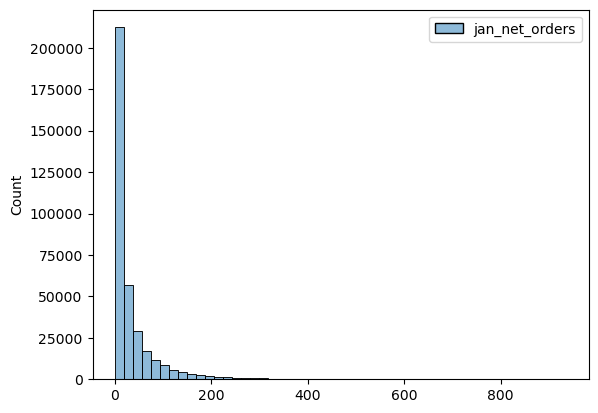

In [60]:
sns.histplot(data=df_for_link_analysis[['jan_net_orders']], bins=50)

In [61]:
df_for_link_analysis.groupby(['jan_net_orders']).agg({'captain_id' : 'nunique'}).reset_index()

,jan_net_orders,captain_id
0,1,34025
1,2,23580
2,3,19358
3,4,16559
4,5,14609
...,...,...
708,846,1
709,881,1
710,883,1
711,929,1


In [62]:
df_for_link_analysis['jan_net_orders'].quantile([0, 0.25, 0.50, 0.75, 1])

0.00      1.0
0.25      4.0
0.50     14.0
0.75     40.0
1.00    935.0
Name: jan_net_orders, dtype: float64

In [63]:
jan_net_orders_threshold = df_for_link_analysis['jan_net_orders'].quantile(0.25)
print(jan_net_orders_threshold)

4.0


#### Filtering captains based on monthly net rides (Criteria: Captain's Jan net orders should  > Q1) 

In [64]:
df_for_link_analysis = df_for_link_analysis[df_for_link_analysis['jan_net_orders'] > jan_net_orders_threshold]
df_for_link_analysis.head(3)

,city_name,service_name,captain_id,jan_net_orders,jan_routeDiff_orders,jan_route_perc,jan_route_group,dec_net_orders,dec_routeDiff_orders,dec_route_perc,dec_route_group,performance,consistency,segment
0,Hyderabad,Link,62444b04f42d27879ba81a4b,46,14.0,30.43,Medium,245,59.0,24.08,Medium,MP,daily,MP_daily
1,Bangalore,Link,64e8ba90f8c3b3710b9f6fa2,114,25.0,21.93,Low,139,31.0,22.30,Low,HP,daily,HP_daily
2,Hyderabad,Link,64e30a444c7007d2a09d8893,97,24.0,24.74,Low,29,3.0,10.34,Low,MP,daily,MP_daily


In [65]:
df_link_analysis0 = df_for_link_analysis\
.groupby(['service_name', 'performance'])\
.agg(captains = pd.NamedAgg('captain_id','nunique'),
     jan_net_orders = pd.NamedAgg('jan_net_orders','sum'),
     jan_routeDiff_orders = pd.NamedAgg('jan_routeDiff_orders','sum')
    )\
.reset_index()
df_link_analysis0['jan %'] = (df_link_analysis0['jan_routeDiff_orders']*100.00/df_link_analysis0['jan_net_orders']).round(2)
df_link_analysis0

,service_name,performance,captains,jan_net_orders,jan_routeDiff_orders,jan %
0,Link,HP,33016,3209036,929475.0,28.96
1,Link,LP,99210,2041605,745271.0,36.50
2,Link,MP,128911,5610489,1772760.0,31.60
3,Link,UHP,7874,1731201,488367.0,28.21


In [66]:
df_link_analysis1 = df_for_link_analysis\
.groupby(['service_name', 'jan_route_group', 'performance'])\
.agg(captains = pd.NamedAgg('captain_id','nunique'),
     jan_net_orders = pd.NamedAgg('jan_net_orders','sum'),
     jan_routeDiff_orders = pd.NamedAgg('jan_routeDiff_orders','sum')
    )\
.reset_index()
df_link_analysis1['jan %'] = (df_link_analysis1['jan_routeDiff_orders']*100.00/df_link_analysis1['jan_net_orders']).round(2)
df_link_analysis1

,service_name,jan_route_group,performance,captains,jan_net_orders,jan_routeDiff_orders,jan %
0,Link,Low,HP,12366,1159008,241053.0,20.80
1,Link,Low,LP,27485,497547,93561.0,18.80
2,Link,Low,MP,40273,1617052,326772.0,20.21
3,Link,Low,UHP,3149,760238,158882.0,20.90
4,Link,Medium,HP,11404,1320493,379836.0,28.76
5,Link,Medium,LP,19995,435110,129615.0,29.79
6,Link,Medium,MP,37399,1954232,573735.0,29.36
7,Link,Medium,UHP,2578,608041,171427.0,28.19
8,Link,High,HP,8992,727096,308586.0,42.44
9,Link,High,LP,48488,1085805,522095.0,48.08


jan_route_group -> Higher (LP, MP, UHP, HP)

In [67]:
df_link_analysis2 = df_for_link_analysis\
.groupby(['jan_route_group', 'dec_route_group'])\
.agg(captains = pd.NamedAgg('captain_id','nunique'),
     jan_net_orders = pd.NamedAgg('jan_net_orders','sum'),
     jan_routeDiff_orders = pd.NamedAgg('jan_routeDiff_orders','sum'),
     dec_net_orders = pd.NamedAgg('dec_net_orders','sum'),
     dec_routeDiff_orders = pd.NamedAgg('dec_routeDiff_orders','sum')
    )\
.reset_index()
df_link_analysis2['jan %'] = (df_link_analysis2['jan_routeDiff_orders']*100.00/df_link_analysis2['jan_net_orders']).round(2)
df_link_analysis2['dec %'] = (df_link_analysis2['dec_routeDiff_orders']*100.00/df_link_analysis2['dec_net_orders']).round(2)
df_link_analysis2['% cap distr'] = (df_link_analysis2['captains']*100.00/df_link_analysis2.captains.sum()).round(2)

df_link_analysis2

,jan_route_group,dec_route_group,captains,jan_net_orders,jan_routeDiff_orders,dec_net_orders,dec_routeDiff_orders,jan %,dec %,% cap distr
0,Low,Low,21077,1617470,322061.0,1821023,350602.0,19.91,19.25,12.53
1,Low,Medium,15425,1003700,213641.0,1245187,332463.0,21.29,26.70,9.17
2,Low,High,16332,508834,104852.0,514935,189832.0,20.61,36.87,9.71
3,Medium,Low,12551,876547,249367.0,914698,186527.0,28.45,20.39,7.46
4,Medium,Medium,16210,1450699,418552.0,1635811,443603.0,28.85,27.12,9.63
5,Medium,High,18963,1043374,309239.0,945704,343728.0,29.64,36.35,11.27
6,High,Low,9117,254588,102509.0,332509,65056.0,40.26,19.57,5.42
7,High,Medium,12757,526705,208608.0,743928,205119.0,39.61,27.57,7.58
8,High,High,45845,2312374,1056859.0,2343936,1000994.0,45.70,42.71,27.24


Totally ~27% of Link captains repeatedly doing more routeDiff orders  

### Auto

In [68]:
df_for_auto_analysis = df_analysis[(df_analysis['service_name'].isin(['Auto']))]

#### Get the distribution for monthly net orders 

<Axes: ylabel='Count'>

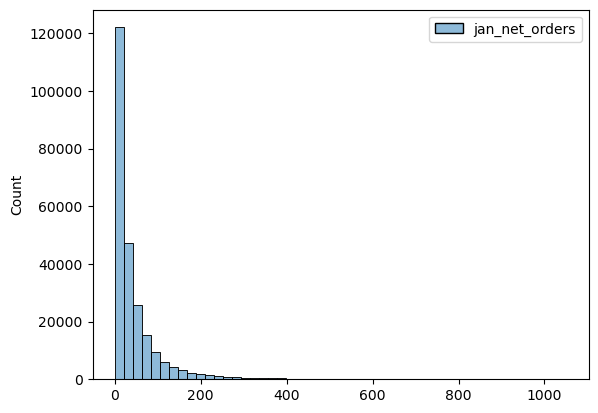

In [69]:
sns.histplot(data=df_for_auto_analysis[['jan_net_orders']], bins=50)

In [70]:
df_for_auto_analysis.groupby(['jan_net_orders']).agg({'captain_id' : 'nunique'}).reset_index()

,jan_net_orders,captain_id
0,1,15972
1,2,11246
2,3,8983
3,4,7663
4,5,7265
...,...,...
850,1014,1
851,1021,1
852,1022,1
853,1046,1


In [71]:
df_for_auto_analysis['jan_net_orders'].quantile([0, 0.25, 0.50, 0.75, 1])

0.00       1.0
0.25       7.0
0.50      22.0
0.75      53.0
1.00    1050.0
Name: jan_net_orders, dtype: float64

In [72]:
jan_net_orders_threshold_auto = df_for_auto_analysis['jan_net_orders'].quantile(0.25)
print(jan_net_orders_threshold_auto)

7.0


#### Filtering captains based on monthly net rides (Criteria: Captain's Jan net orders should  > Q1) 

In [73]:
df_for_auto_analysis = df_for_auto_analysis[df_for_auto_analysis['jan_net_orders'] > jan_net_orders_threshold_auto]
df_for_auto_analysis.head(3)

,city_name,service_name,captain_id,jan_net_orders,jan_routeDiff_orders,jan_route_perc,jan_route_group,dec_net_orders,dec_routeDiff_orders,dec_route_perc,dec_route_group,performance,consistency,segment
5,Jaipur,Auto,613614de7f5ff7d78cfe1644,25,7.0,28.00,Medium,15,4.0,26.67,Medium,LP,intra,LP_intra
6,Bangalore,Auto,5c7fbddd8c352421eadc6868,476,77.0,16.18,Low,792,111.0,14.02,Low,UHP,daily,UHP_daily
7,Bangalore,Auto,60e87fa1ac6ff43823605e4c,203,54.0,26.60,Medium,181,50.0,27.62,High,HP,daily,HP_daily


In [74]:
df_auto_analysis0 = df_for_auto_analysis\
.groupby(['service_name', 'performance'])\
.agg(captains = pd.NamedAgg('captain_id','nunique'),
     jan_net_orders = pd.NamedAgg('jan_net_orders','sum'),
     jan_routeDiff_orders = pd.NamedAgg('jan_routeDiff_orders','sum')
    )\
.reset_index()
df_auto_analysis0['jan %'] = (df_auto_analysis0['jan_routeDiff_orders']*100.00/df_auto_analysis0['jan_net_orders']).round(2)
df_auto_analysis0

,service_name,performance,captains,jan_net_orders,jan_routeDiff_orders,jan %
0,Auto,HP,16280,2710530,621798.0,22.94
1,Auto,LP,88655,2175266,660274.0,30.35
2,Auto,MP,73205,4583550,1245582.0,27.18
3,Auto,UHP,3972,1566681,244595.0,15.61


In [75]:
df_auto_analysis1 = df_for_auto_analysis\
.groupby(['service_name', 'jan_route_group', 'performance'])\
.agg(captains = pd.NamedAgg('captain_id','nunique'),
     jan_net_orders = pd.NamedAgg('jan_net_orders','sum'),
     jan_routeDiff_orders = pd.NamedAgg('jan_routeDiff_orders','sum')
    )\
.reset_index()
df_auto_analysis1['jan %'] = (df_auto_analysis1['jan_routeDiff_orders']*100.00/df_auto_analysis1['jan_net_orders']).round(2)
df_auto_analysis1

,service_name,jan_route_group,performance,captains,jan_net_orders,jan_routeDiff_orders,jan %
0,Auto,Low,HP,5844,995831,151793.0,15.24
1,Auto,Low,LP,20315,442275,65192.0,14.74
2,Auto,Low,MP,19567,1119526,169536.0,15.14
3,Auto,Low,UHP,2816,1203894,156197.0,12.97
4,Auto,Medium,HP,6342,1114079,269055.0,24.15
5,Auto,Medium,LP,21234,551749,136647.0,24.77
6,Auto,Medium,MP,22367,1507154,369916.0,24.54
7,Auto,Medium,UHP,946,318820,74186.0,23.27
8,Auto,High,HP,4032,599655,200950.0,33.51
9,Auto,High,LP,45520,1163510,458435.0,39.40


jan_route_group -> Higher (LP, MP, HP, UHP)

In [76]:
df_auto_analysis2 = df_for_auto_analysis\
.groupby(['jan_route_group', 'dec_route_group'])\
.agg(captains = pd.NamedAgg('captain_id','nunique'),
     jan_net_orders = pd.NamedAgg('jan_net_orders','sum'),
     jan_routeDiff_orders = pd.NamedAgg('jan_routeDiff_orders','sum'),
     dec_net_orders = pd.NamedAgg('dec_net_orders','sum'),
     dec_routeDiff_orders = pd.NamedAgg('dec_routeDiff_orders','sum')
    )\
.reset_index()
df_auto_analysis2['jan %'] = (df_auto_analysis2['jan_routeDiff_orders']*100.00/df_auto_analysis2['jan_net_orders']).round(2)
df_auto_analysis2['dec %'] = (df_auto_analysis2['dec_routeDiff_orders']*100.00/df_auto_analysis2['dec_net_orders']).round(2)
df_auto_analysis2['% cap distr'] = (df_auto_analysis2['captains']*100.00/df_auto_analysis2.captains.sum()).round(2)

df_auto_analysis2

,jan_route_group,dec_route_group,captains,jan_net_orders,jan_routeDiff_orders,dec_net_orders,dec_routeDiff_orders,jan %,dec %,% cap distr
0,Low,Low,21425,2493113,342205.0,2449225,329769.0,13.73,13.46,14.00
1,Low,Medium,9155,615789,101786.0,624663,144127.0,16.53,23.07,5.98
2,Low,High,9144,306310,48980.0,255895,86772.0,15.99,33.91,5.98
3,Medium,Low,11939,821957,193043.0,807601,133479.0,23.49,16.53,7.80
4,Medium,Medium,14271,1353906,328575.0,1367899,324219.0,24.27,23.70,9.33
5,Medium,High,17446,1015927,255256.0,889805,293282.0,25.13,32.96,11.40
6,High,Low,8713,291911,102447.0,285108,46234.0,35.10,16.22,5.69
7,High,Medium,13867,757422,259845.0,841037,205543.0,34.31,24.44,9.06
8,High,High,47034,2384712,896614.0,2333727,848732.0,37.60,36.37,30.74


Totally ~30% of Auto captains repeatedly doing more routeDiff orders  

## Key 

In [77]:
print('Link')
df_link_analysis2

Link


,jan_route_group,dec_route_group,captains,jan_net_orders,jan_routeDiff_orders,dec_net_orders,dec_routeDiff_orders,jan %,dec %,% cap distr
0,Low,Low,21077,1617470,322061.0,1821023,350602.0,19.91,19.25,12.53
1,Low,Medium,15425,1003700,213641.0,1245187,332463.0,21.29,26.70,9.17
2,Low,High,16332,508834,104852.0,514935,189832.0,20.61,36.87,9.71
3,Medium,Low,12551,876547,249367.0,914698,186527.0,28.45,20.39,7.46
4,Medium,Medium,16210,1450699,418552.0,1635811,443603.0,28.85,27.12,9.63
5,Medium,High,18963,1043374,309239.0,945704,343728.0,29.64,36.35,11.27
6,High,Low,9117,254588,102509.0,332509,65056.0,40.26,19.57,5.42
7,High,Medium,12757,526705,208608.0,743928,205119.0,39.61,27.57,7.58
8,High,High,45845,2312374,1056859.0,2343936,1000994.0,45.70,42.71,27.24


Totally 27.24% of Link captains repeatedly doing more routeDiff orders  

In [78]:
print('Auto')
df_auto_analysis2

Auto


,jan_route_group,dec_route_group,captains,jan_net_orders,jan_routeDiff_orders,dec_net_orders,dec_routeDiff_orders,jan %,dec %,% cap distr
0,Low,Low,21425,2493113,342205.0,2449225,329769.0,13.73,13.46,14.00
1,Low,Medium,9155,615789,101786.0,624663,144127.0,16.53,23.07,5.98
2,Low,High,9144,306310,48980.0,255895,86772.0,15.99,33.91,5.98
3,Medium,Low,11939,821957,193043.0,807601,133479.0,23.49,16.53,7.80
4,Medium,Medium,14271,1353906,328575.0,1367899,324219.0,24.27,23.70,9.33
5,Medium,High,17446,1015927,255256.0,889805,293282.0,25.13,32.96,11.40
6,High,Low,8713,291911,102447.0,285108,46234.0,35.10,16.22,5.69
7,High,Medium,13867,757422,259845.0,841037,205543.0,34.31,24.44,9.06
8,High,High,47034,2384712,896614.0,2333727,848732.0,37.60,36.37,30.74


Totally 30.7% of Auto captains repeatedly doing more routeDiff orders  

## Other

In [79]:
df_for_link_analysis.head(5)

,city_name,service_name,captain_id,jan_net_orders,jan_routeDiff_orders,jan_route_perc,jan_route_group,dec_net_orders,dec_routeDiff_orders,dec_route_perc,dec_route_group,performance,consistency,segment
0,Hyderabad,Link,62444b04f42d27879ba81a4b,46,14.0,30.43,Medium,245,59.0,24.08,Medium,MP,daily,MP_daily
1,Bangalore,Link,64e8ba90f8c3b3710b9f6fa2,114,25.0,21.93,Low,139,31.0,22.30,Low,HP,daily,HP_daily
2,Hyderabad,Link,64e30a444c7007d2a09d8893,97,24.0,24.74,Low,29,3.0,10.34,Low,MP,daily,MP_daily
4,Delhi,Link,6501608099739db103ed12fa,9,3.0,33.33,Medium,159,49.0,30.82,Medium,MP,intra_week,MP_intra_week
8,Hyderabad,Link,648874a6109430b8692c06ed,15,4.0,26.67,Medium,0,NaN,NaN,NaN,MP,inter_week,MP_inter_week


In [80]:
df_for_link_analysis.head(5).to_clipboard(index=False)

In [81]:
df_for_auto_analysis.head(5)

,city_name,service_name,captain_id,jan_net_orders,jan_routeDiff_orders,jan_route_perc,jan_route_group,dec_net_orders,dec_routeDiff_orders,dec_route_perc,dec_route_group,performance,consistency,segment
5,Jaipur,Auto,613614de7f5ff7d78cfe1644,25,7.0,28.00,Medium,15,4.0,26.67,Medium,LP,intra,LP_intra
6,Bangalore,Auto,5c7fbddd8c352421eadc6868,476,77.0,16.18,Low,792,111.0,14.02,Low,UHP,daily,UHP_daily
7,Bangalore,Auto,60e87fa1ac6ff43823605e4c,203,54.0,26.60,Medium,181,50.0,27.62,High,HP,daily,HP_daily
10,Hyderabad,Auto,5f3104242a287dd2bc228954,45,16.0,35.56,High,86,35.0,40.70,High,LP,daily,LP_daily
11,Hyderabad,Auto,5f47554fbe98be2b55357663,91,19.0,20.88,Medium,61,8.0,13.11,Low,MP,daily,MP_daily


In [82]:
df_for_auto_analysis.head(5).to_clipboard(index=False)